In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import math
import gc
import os
import sys
import functools
os.environ["HF_HOME"] = "/cs/student/project_msc/2025/csml/katayama/huggingface_cache_marin/kestrel"
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from datasets import load_dataset
from tqdm.std import tqdm
import itertools
import glob
import re
import numpy as np
from sklearn.decomposition import IncrementalPCA
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt

In [2]:
# Import custom module
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

%load_ext autoreload
%autoreload 2

from modules.experiment_helpers import set_seed

In [3]:
model_id = "marin-community/marin-8b-base"
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)
subject = "all"
batch_size = 2
Trained = True
Parameter_Obtained = True
set_seed(42)

cuda


In [4]:
if not Trained:
    print(f"loading {model_id}...")
    tokenizer = AutoTokenizer.from_pretrained(model_id, revision="kestrel")
    tokenizer.padding_side = "left"
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    quantization_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_compute_dtype=torch.bfloat16,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type="nf4"
    )

    model = AutoModelForCausalLM.from_pretrained(
        model_id,
        dtype=torch.bfloat16,
        device_map="auto", 
        quantization_config=quantization_config,
        revision="kestrel"
    )
    model.eval()

In [5]:
if not Trained: 
    print(f"loading MMLU ({subject})...")
    dataset = load_dataset("cais/mmlu", subject, split="test")

In [6]:
if not Trained: 
    choices = ["A", "B", "C", "D"]
    choice_ids = [tokenizer.encode(c, add_special_tokens=False)[-1] for c in choices]
    prompt_template = "Question: {question}\nA. {a}\nB. {b}\nC. {c}\nD. {d}\nAnswer: "

In [7]:
if not Trained:
    prompts = []
    answers = []
    for sample in dataset:
        p = prompt_template.format(
            question=sample['question'],
            a=sample['choices'][0],
            b=sample['choices'][1],
            c=sample['choices'][2],
            d=sample['choices'][3]
        )
        prompts.append(p)
        answers.append(sample['answer'])

    correct_count = 0
    total_count = len(dataset)

In [8]:
save_dir = "Result/publish/marine_chunks_kestrel"
os.makedirs(save_dir, exist_ok=True)
if not Trained:
    tokenizer.padding_side = 'left'
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    target_layers_list = [0, 7, 15, 23, 31]
    num_heads = model.config.num_attention_heads
    head_dim = model.config.hidden_size // num_heads

    activation_cache = {}
    correct_count = 0
    total_count = len(dataset)

    # ==========================================
    # 1. Define hook: Extract pure vectors just before entering o_proj (before mixing)
    # ==========================================
    def get_attention_pre_hook(layer_idx, module, input):
        # The input to o_proj passed as a Tuple
        x = input[0] # Shape: [Batch, Seq_Len, Hidden_Dim]
        batch_size, seq_len, _ = x.shape

        # Split into individual heads before mixing
        head_outputs = x.view(batch_size, seq_len, num_heads, head_dim)

        # Calculate L2 norm
        head_l2_norms = torch.norm(head_outputs, p=2, dim=-1)
        activation_cache[layer_idx] = head_l2_norms

    handles = []
    for layer_idx in target_layers_list:
        hook_fn = functools.partial(get_attention_pre_hook, layer_idx)
        # Attach register_forward_pre_hook to o_proj
        handle = model.model.layers[layer_idx].self_attn.o_proj.register_forward_pre_hook(hook_fn)
        handles.append(handle)

    group1_S_dict = {layer: [] for layer in target_layers_list}
    group2_S_dict = {layer: [] for layer in target_layers_list}
    group1_T_list = []
    group2_T_list = []

    print("="*50)
    print(f"Starting feature extraction & evaluation loop...")
    print("="*50)

    # ==========================================
    # 2. Extraction loop (10-token generation)
    # ==========================================
    chunk_size = 50 
    batch_counter = 0
    chunk_idx = 0

    print("="*50)
    print(f"10-token generation version: Starting feature extraction & split saving...")
    print(f"Save directory: {save_dir}")
    print("="*50)

    for i in tqdm(range(0, total_count, batch_size), disable = True):
        batch_prompts = prompts[i:i+batch_size]
        batch_answers = answers[i:i+batch_size]
        
        if not batch_prompts: continue

        inputs = tokenizer(batch_prompts, return_tensors="pt", padding=True, truncation=True, max_length=1024)
        inputs = {k: v.to(device) for k, v in inputs.items()}
        prompt_lengths = inputs['attention_mask'].sum(dim=1)

        try:
            # --------------------------------------------------
            # STEP 1: Generate 10 tokens without hooks (Avoid OOM)
            # --------------------------------------------------
            with torch.inference_mode():
                gen_outputs = model.generate(
                    **inputs,
                    max_new_tokens=10,  # Generate exactly 10 tokens
                    do_sample=False,
                    pad_token_id=tokenizer.pad_token_id,
                    eos_token_id=tokenizer.eos_token_id
                )
            
            # --------------------------------------------------
            # STEP 2: Attach hooks and calculate the full sequence
            # --------------------------------------------------
            handles = []
            for layer_idx in target_layers_list:
                hook_fn = functools.partial(get_attention_pre_hook, layer_idx)
                handle = model.model.layers[layer_idx].self_attn.o_proj.register_forward_pre_hook(hook_fn)
                handles.append(handle)

            activation_cache.clear()
            
            # Create a full attention mask to ignore PAD tokens
            full_attention_mask = (gen_outputs != tokenizer.pad_token_id).long()
            
            with torch.inference_mode():
                # 最終層の隠れ状態は不要になるため、output_hidden_states=Falseでメモリ節約
                model(gen_outputs, attention_mask=full_attention_mask, output_hidden_states=False)
                
                # ★ NEW: 生成された全トークンIDをモデルの埋め込み層に通し、単語エンベディングを取得
                # shape: [Batch, Seq_Len, Hidden_Dim]
                all_token_embeddings = model.get_input_embeddings()(gen_outputs)

            # --------------------------------------------------
            # STEP 3: Accurate slice splitting considering Left Padding
            # --------------------------------------------------
            # Maximum length of prompt tensor (including PAD)
            max_prompt_len = inputs['input_ids'].shape[1] 

            for j in range(len(batch_prompts)):
                p_len = prompt_lengths[j].item() # Number of valid tokens in the prompt
                
                # Number of new tokens actually generated in that sequence
                gen_len = (gen_outputs[j] != tokenizer.pad_token_id).sum().item() - p_len
                
                if gen_len <= 0:
                    continue
                    
                # Correct index calculation considering Left Padding
                prompt_start = max_prompt_len - p_len     # Prompt start position
                prompt_end = max_prompt_len               # Prompt end position (generation start position)
                gen_end = max_prompt_len + gen_len        # End position of the generated text

                # [Group 2: Context Accumulation (Prompt part)]
                # ★ S(時刻t) から予測される T(時刻t+1) のエンベディングを取得するため、Tのインデックスを +1 ずらす
                T_g2 = all_token_embeddings[j, prompt_start+1:prompt_end, :].detach().cpu()
                group2_T_list.append(T_g2)
                
                for layer_idx in target_layers_list:
                    S_g2 = activation_cache[layer_idx][j, prompt_start:prompt_end-1, :].detach().cpu()
                    group2_S_dict[layer_idx].append(S_g2)

                # [Group 1: Inference Decision (Newly generated 10 tokens)]
                # ★ ここも同様に T のインデックスを +1 ズラす (prompt_end-1+1 = prompt_end)
                T_g1 = all_token_embeddings[j, prompt_end:gen_end, :].detach().cpu()
                group1_T_list.append(T_g1)
                
                for layer_idx in target_layers_list:
                    S_g1 = activation_cache[layer_idx][j, prompt_end-1:gen_end-1, :].detach().cpu()
                    group1_S_dict[layer_idx].append(S_g1)
            # --------------------------------------------------
            # STEP 4: Remove hooks and free memory
            # --------------------------------------------------
            for handle in handles:
                handle.remove()

            batch_counter += 1
            if batch_counter >= chunk_size:
                torch.save(torch.cat(group1_T_list, dim=0), f"{save_dir}/T_g1_chunk_{chunk_idx}.pt")
                torch.save(torch.cat(group2_T_list, dim=0), f"{save_dir}/T_g2_chunk_{chunk_idx}.pt")
                group1_T_list.clear()
                group2_T_list.clear()

                for layer in target_layers_list:
                    torch.save(torch.cat(group1_S_dict[layer], dim=0), f"{save_dir}/S_g1_layer{layer}_chunk_{chunk_idx}.pt")
                    torch.save(torch.cat(group2_S_dict[layer], dim=0), f"{save_dir}/S_g2_layer{layer}_chunk_{chunk_idx}.pt")
                    group1_S_dict[layer].clear()
                    group2_S_dict[layer].clear()

                chunk_idx += 1
                batch_counter = 0

        except torch.cuda.OutOfMemoryError:
            print(f"OOM Error at batch {i}. Skipping...")
            for handle in handles:
                handle.remove()
            pass
        finally:
            activation_cache.clear()
            torch.cuda.empty_cache()
            gc.collect()

    # ==========================================
    # Final save for remaining chunks
    # ==========================================
    if len(group1_T_list) > 0:
        torch.save(torch.cat(group1_T_list, dim=0), f"{save_dir}/T_g1_chunk_{chunk_idx}.pt")
        if len(group2_T_list) > 0:
            torch.save(torch.cat(group2_T_list, dim=0), f"{save_dir}/T_g2_chunk_{chunk_idx}.pt")
        group1_T_list.clear()
        group2_T_list.clear()

        for layer in target_layers_list:
            torch.save(torch.cat(group1_S_dict[layer], dim=0), f"{save_dir}/S_g1_layer{layer}_chunk_{chunk_idx}.pt")
            if len(group2_S_dict[layer]) > 0:
                torch.save(torch.cat(group2_S_dict[layer], dim=0), f"{save_dir}/S_g2_layer{layer}_chunk_{chunk_idx}.pt")
            group1_S_dict[layer].clear()
            group2_S_dict[layer].clear()

    print(f"\nExtraction & Saving complete. A total of {chunk_idx + 1} chunk files were created.")

In [9]:
# ==========================================
# 1. Dimensionality reduction of T (PCA: 4096 -> 128)
# ==========================================
import glob
import re
import numpy as np
import torch
from sklearn.decomposition import IncrementalPCA
from tqdm.std import tqdm

if not Parameter_Obtained: 
    print("Starting PCA dimensionality reduction (Incremental PCA version) for the target variable T...")
    reduced_dim = 128

    def get_chunk_idx(filename):
        match = re.search(r'chunk_(\d+)\.pt', filename)
        return int(match.group(1)) if match else -1

    g1_files = sorted(glob.glob(f"{save_dir}/T_g1_chunk_*.pt"), key=get_chunk_idx)
    g2_files = sorted(glob.glob(f"{save_dir}/T_g2_chunk_*.pt"), key=get_chunk_idx)

    ipca = IncrementalPCA(n_components=reduced_dim)

    # ==========================================
    # 2. Train PCA axes
    # ==========================================
    print("Training PCA axes (partial_fit)...")
    all_files = g1_files + g2_files

    buffer = []
    buffer_size = 0
    min_samples = 512

    for f in tqdm(all_files, desc="Fitting PCA", disable=True):
        chunk_data = torch.load(f, map_location='cpu').to(torch.float32).numpy()

        # Downsample the massive Group 2 data randomly to a maximum of 1000 samples
        if chunk_data.shape[0] > 1000:
            indices = np.random.choice(chunk_data.shape[0], size=1000, replace=False)
            chunk_data = chunk_data[indices]

        buffer.append(chunk_data)
        buffer_size += chunk_data.shape[0]

        if buffer_size >= min_samples:
            batch_data = np.vstack(buffer)
            ipca.partial_fit(batch_data)
            buffer = []
            buffer_size = 0
            del batch_data

    if len(buffer) > 0:
        batch_data = np.vstack(buffer)
        if batch_data.shape[0] >= reduced_dim:
            ipca.partial_fit(batch_data)
        del buffer
        del batch_data

    # ==========================================
    # 3. Projection of Group 1
    # ==========================================
    print("Projecting Group 1 data...")
    T_group1_pca_list = []
    for f in tqdm(g1_files, desc="Transforming G1", disable=True):
        chunk_data = torch.load(f, map_location='cpu').to(torch.float32).numpy()
        transformed = ipca.transform(chunk_data) # No error occurs during transformation even with few samples
        T_group1_pca_list.append(torch.tensor(transformed, dtype=torch.float32))
        del chunk_data

    # ==========================================
    # 4. Projection of Group 2
    # ==========================================
    print("Projecting Group 2 data...")
    T_group2_pca_list = []
    for f in tqdm(g2_files, desc="Transforming G2", disable=True):
        chunk_data = torch.load(f, map_location='cpu').to(torch.float32).numpy()
        transformed = ipca.transform(chunk_data)
        T_group2_pca_list.append(torch.tensor(transformed, dtype=torch.float32))
        del chunk_data

    # ==========================================
    # 5. Concatenation and L2 normalization (No changes here)
    # ==========================================
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    T_group1_pca = torch.cat(T_group1_pca_list, dim=0)
    T_group2_pca = torch.cat(T_group2_pca_list, dim=0)

    print(f"PCA complete: Reduced dimensionality is {T_group1_pca.shape[1]}")

    print("Restoring the concatenation of S (L2 norm) data...")

    target_layers_list = [0, 7, 15, 23, 31]
    final_S_group1 = {}
    final_S_group2 = {}

    for layer in target_layers_list:
        # --- Concatenation of Group 1 (Inference tokens) ---
        s_g1_files = sorted(glob.glob(f"{save_dir}/S_g1_layer{layer}_chunk_*.pt"), key=get_chunk_idx)
        # Load as float32 to prevent BFloat16 errors
        s_g1_tensors = [torch.load(f, map_location='cpu').to(torch.float32) for f in s_g1_files]
        final_S_group1[layer] = torch.cat(s_g1_tensors, dim=0)

        # --- Concatenation of Group 2 (Context tokens) ---
        s_g2_files = sorted(glob.glob(f"{save_dir}/S_g2_layer{layer}_chunk_*.pt"), key=get_chunk_idx)
        s_g2_tensors = [torch.load(f, map_location='cpu').to(torch.float32) for f in s_g2_files]
        final_S_group2[layer] = torch.cat(s_g2_tensors, dim=0)

    print("S data concatenation completed")
    print(f"Restored keys for final_S_group1: {list(final_S_group1.keys())}")

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
data_save_path = "Result/publish/LLM/marin/kestrel.pt"

if not Parameter_Obtained: 
    # ==========================================
    # 1. Model Definitions (Linear Synergy Model + Universal Approximation MLP)
    # ==========================================
    class GaussianSynergyModel(nn.Module):
        def __init__(self, num_heads, target_dim, k):
            super().__init__()
            self.k = k
            self.combo_indices = {}
            self.thetas = nn.ParameterDict()
            self.theta_T = nn.Parameter(torch.zeros(target_dim))
            
            for i in range(1, k + 1):
                combos = torch.combinations(torch.arange(num_heads), r=i)
                self.combo_indices[str(i)] = combos
                init_scale = 0.01 / math.sqrt(combos.shape[0])
                self.thetas[str(i)] = nn.Parameter(torch.randn(combos.shape[0], target_dim) * init_scale)

        def forward(self, S):
            mu = self.theta_T.unsqueeze(0).expand(S.shape[0], -1)
            if self.k == 0:
                return mu
            for i in range(1, self.k + 1):
                combos = self.combo_indices[str(i)].to(S.device)
                theta_i = self.thetas[str(i)]
                S_prod = torch.prod(S[:, combos], dim=2)
                mu_i = torch.matmul(S_prod, theta_i) / combos.shape[0]
                mu = mu + mu_i
            return mu

    class TrueTotalSynergyMLP(nn.Module):
        def __init__(self, num_heads, target_dim):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(num_heads, 512),
                nn.GELU(),
                nn.Linear(512, 512),
                nn.GELU(),
                nn.Linear(512, target_dim)
            )

        def forward(self, S):
            return self.net(S)

    # ==========================================
    # 2. Integrated CV Loop (Returns cumulative KL history, Total MI, and Val MSE)
    # ==========================================
    def calculate_all_kl_and_total_mi(S_tensor, T_tensor, max_k=5, epochs=100, n_splits=3, batch_size=1024):
        target_dim = T_tensor.shape[1]
        num_heads = S_tensor.shape[1]
        total_samples = S_tensor.shape[0]
        
        lr_candidates = [1e-4, 1e-3]
        wd_candidates = [0.0, 1e-4, 1e-2]
        
        kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
        kl_results = {0: 0.0}
        total_mi = 0.0
        
        # ★ ADDED: Dictionary to keep track of the best Val MSE for each step
        val_mse_results = {}
        
        models_k0_per_fold = []
        sigma2_k0_per_fold = []
        
        prev_models_per_fold = []
        prev_sigma2_per_fold = []
        
        steps = list(range(max_k + 1)) + ['Total_MI']
        
        for step in steps:
            step_name = f"k={step}" if isinstance(step, int) else "MLP (Total MI)"
            print(f"      -> Degree {step_name}: Searching for optimal parameters via CV...")
            
            best_val_mse = float('inf')
            best_params = (lr_candidates[0], wd_candidates[0])
            best_models = []
            
            for lr, wd in itertools.product(lr_candidates, wd_candidates):
                val_mse_list = []
                current_temp_models = []
                
                for train_idx, val_idx in kf.split(X=np.zeros(total_samples)):
                    S_train, T_train = S_tensor[train_idx], T_tensor[train_idx]
                    S_val, T_val = S_tensor[val_idx], T_tensor[val_idx]
                    
                    if step == 'Total_MI':
                        model = TrueTotalSynergyMLP(num_heads, target_dim).to(S_tensor.device)
                    else:
                        model = GaussianSynergyModel(num_heads, target_dim, step).to(S_tensor.device)
                        
                    optimizer = optim.Adam(model.parameters(), lr=lr)
                    
                    for _ in range(epochs):
                        indices = torch.randperm(S_train.shape[0])
                        for start_idx in range(0, S_train.shape[0], batch_size):
                            b_idx = indices[start_idx:start_idx + batch_size]
                            S_b, T_b = S_train[b_idx], T_train[b_idx]
                            
                            optimizer.zero_grad()
                            mse_loss = F.mse_loss(model(S_b), T_b)
                            
                            l1_penalty = 0.0
                            for param in model.parameters():
                                l1_penalty += torch.sum(torch.abs(param))
                                
                            loss = mse_loss + wd * l1_penalty
                            loss.backward()
                            optimizer.step()
                            
                    with torch.no_grad():
                        val_mse_sum = 0.0
                        for start_idx in range(0, S_val.shape[0], batch_size):
                            S_b = S_val[start_idx:start_idx + batch_size]
                            T_b = T_val[start_idx:start_idx + batch_size]
                            val_mse_sum += F.mse_loss(model(S_b), T_b, reduction='sum').item()
                        val_mse = val_mse_sum / (S_val.shape[0] * target_dim)
                        val_mse_list.append(val_mse)
                    
                    current_temp_models.append(model)
                    
                avg_val_mse = sum(val_mse_list) / n_splits
                if avg_val_mse < best_val_mse:
                    best_val_mse = avg_val_mse
                    best_params = (lr, wd)
                    best_models = current_temp_models
                    
            print(f"         [CV Complete] Optimal parameters: lr={best_params[0]}, wd={best_params[1]} (Val MSE={best_val_mse:.4f})")
            
            # ★ ADDED: Store the best Val MSE for this step
            val_mse_results[step] = best_val_mse
            current_models_per_fold = best_models
                
            if step == 0:
                models_k0_per_fold = current_models_per_fold
                prev_models_per_fold = current_models_per_fold
                
                fold_idx = 0
                for train_idx, val_idx in kf.split(X=np.zeros(total_samples)):
                    S_val, T_val = S_tensor[val_idx], T_tensor[val_idx]
                    model_0 = current_models_per_fold[fold_idx]
                    
                    with torch.no_grad():
                        mse_0_sum = 0.0
                        for start_idx in range(0, S_val.shape[0], batch_size):
                            S_b = S_val[start_idx:start_idx+batch_size]
                            T_b = T_val[start_idx:start_idx+batch_size]
                            mse_0_sum += F.mse_loss(model_0(S_b), T_b, reduction='sum').item()
                        sigma2_0 = mse_0_sum / (S_val.shape[0] * target_dim)
                        sigma2_0 = max(sigma2_0, 1e-8)
                        
                        sigma2_k0_per_fold.append(sigma2_0)
                        prev_sigma2_per_fold.append(sigma2_0)
                    fold_idx += 1
                continue
                
            fold_kl_list = []
            current_sigma2_per_fold = []
            fold_idx = 0
            
            for train_idx, val_idx in kf.split(X=np.zeros(total_samples)):
                S_val, T_val = S_tensor[val_idx], T_tensor[val_idx]
                model_current = current_models_per_fold[fold_idx]
                
                if step == 'Total_MI':
                    model_base = models_k0_per_fold[fold_idx]
                    base_sigma2 = sigma2_k0_per_fold[fold_idx]
                else:
                    model_base = prev_models_per_fold[fold_idx]
                    base_sigma2 = prev_sigma2_per_fold[fold_idx]
                
                with torch.no_grad():
                    mse_mu_sum = 0.0
                    curr_mse_sum = 0.0
                    
                    for start_idx in range(0, S_val.shape[0], batch_size):
                        S_b = S_val[start_idx:start_idx+batch_size]
                        T_b = T_val[start_idx:start_idx+batch_size]
                        
                        mu_curr = model_current(S_b)
                        mu_base = model_base(S_b)
                        
                        mse_mu_sum += F.mse_loss(mu_curr, mu_base, reduction='sum').item()
                        curr_mse_sum += F.mse_loss(mu_curr, T_b, reduction='sum').item()
                    
                    mse_mu = mse_mu_sum / (S_val.shape[0] * target_dim)
                    curr_sigma2 = curr_mse_sum / (S_val.shape[0] * target_dim)
                    curr_sigma2 = max(curr_sigma2, 1e-8)
                    
                    term1 = (curr_sigma2 / base_sigma2) - 1.0 - math.log(curr_sigma2 / base_sigma2)
                    term2 = mse_mu / base_sigma2
                    
                    fold_kl = (target_dim / 2.0) * (term1 + term2)
                    fold_kl_list.append(max(0.0, fold_kl))
                    current_sigma2_per_fold.append(curr_sigma2)
                    
                fold_idx += 1
                
            kl_val = sum(fold_kl_list) / n_splits
            
            if step == 'Total_MI':
                total_mi = kl_val
                print(f"         [Total MI Calculation Complete] MLP vs k=0: Total MI = {total_mi:.4f}")
            else:
                cumulative_kl = kl_results[step-1] + kl_val
                kl_results[step] = cumulative_kl
                print(f"         [KL Calculation Complete] k={step}: Step KL = {kl_val:.4f} | Cumulative KL = {cumulative_kl:.4f}")
                
                prev_models_per_fold = current_models_per_fold
                prev_sigma2_per_fold = current_sigma2_per_fold

        return kl_results, total_mi, val_mse_results


    # ==========================================
    # 3. Integrated Grand Loop (Records plot data for all layers)
    # ==========================================
    print("\n" + "="*60)
    print("[Final Analysis] Information coverage up to k=5 against total MI estimates (All-layer stacked graph version)")
    print("="*60)

    max_eval_k = 5
    sample_limit = 10000 

    plot_layers = []
    
    # ★ CHANGED: Added 'val_mse' dictionary to explicitly track MSE for 0~5 and 'Total_MI'
    data_g1 = {
        'total_mi': [], 1: [], 2: [], 3: [], 4: [], 5: [],
        'val_mse': {0: [], 1: [], 2: [], 3: [], 4: [], 5: [], 'Total_MI': []}
    }
    data_g2 = {
        'total_mi': [], 1: [], 2: [], 3: [], 4: [], 5: [],
        'val_mse': {0: [], 1: [], 2: [], 3: [], 4: [], 5: [], 'Total_MI': []}
    }

    # target_layers_list is assumed to be something like [0, 7, 15, 23, 31]
    for target_layer in target_layers_list:
        layer_name = target_layer + 1
        plot_layers.append(layer_name)
        print(f"\n[Starting analysis for Layer {layer_name}]...")

        # ------------------------------------------------
        # [Group 1: Inference Decision Phase]
        # ------------------------------------------------
        print("   [Group 1: Inference Decision Phase]")
        torch.cuda.empty_cache()
        gc.collect()

        S_g1 = final_S_group1[target_layer][:sample_limit].to(device).float()
        T_g1 = T_group1_pca[:sample_limit].to(device).float()
        kl_res_g1, total_mi_g1, val_mse_g1 = calculate_all_kl_and_total_mi(S_g1, T_g1, max_k=max_eval_k, epochs=500, n_splits=3)
        
        data_g1['total_mi'].append(total_mi_g1)
        for k in range(1, max_eval_k + 1):
            step_kl = max(0.0, kl_res_g1[k] - kl_res_g1[k-1]) 
            data_g1[k].append(step_kl)
            
        # ★ ADDED: Save MSE results into the dictionary
        for step_key, mse_val in val_mse_g1.items():
            data_g1['val_mse'][step_key].append(mse_val)


        # ------------------------------------------------
        # [Group 2: Context Accumulation Phase]
        # ------------------------------------------------
        print("\n   [Group 2: Context Accumulation Phase]")
        torch.cuda.empty_cache()
        gc.collect()

        total_g2_samples = final_S_group2[target_layer].shape[0]
        indices = torch.randperm(total_g2_samples)[:sample_limit]
        
        S_g2 = final_S_group2[target_layer][indices].to(device).float()
        T_g2 = T_group2_pca[indices].to(device).float()

        # ★ CHANGED: Catch the new 3rd return value (val_mse_g2)
        kl_res_g2, total_mi_g2, val_mse_g2 = calculate_all_kl_and_total_mi(S_g2, T_g2, max_k=max_eval_k, epochs=500, n_splits=3)
        
        data_g2['total_mi'].append(total_mi_g2)
        for k in range(1, max_eval_k + 1):
            step_kl = max(0.0, kl_res_g2[k] - kl_res_g2[k-1]) 
            data_g2[k].append(step_kl)
            
        # ★ ADDED: Save MSE results into the dictionary
        for step_key, mse_val in val_mse_g2.items():
            data_g2['val_mse'][step_key].append(mse_val)


    # ==========================================
    # 4. Save Raw Dictionary Data (For future graph adjustments)
    # ==========================================
    print("\n" + "="*60)
    print("Saving raw dictionary data for future plotting...")
    print("="*60)

    saved_data_dict = {
        'plot_layers': plot_layers,
        'data_g1': data_g1,
        'data_g2': data_g2
    }

    os.makedirs(os.path.dirname(data_save_path), exist_ok=True)
    torch.save(saved_data_dict, data_save_path)
    print(f"Raw data saved successfully to '{data_save_path}'. You can load this later using torch.load().")

else:
    print("\n" + "="*60)
    print(f"Loading existing data from '{data_save_path}'...")
    print("="*60)
    
    if os.path.exists(data_save_path):
        saved_data_dict = torch.load(data_save_path)
        plot_layers = saved_data_dict['plot_layers']
        data_g1 = saved_data_dict['data_g1']
        data_g2 = saved_data_dict['data_g2']
        
        if 'val_mse' not in data_g1:
            print("Warning: The loaded .pt file does not contain 'val_mse' history (older format).")
            
        print("Data loaded successfully! Ready for plotting.")
    else:
        print(f"File '{data_save_path}' not found. Set Parameter_Obtained = False")


Loading existing data from 'Result/publish/LLM/marin/kestrel.pt'...
Data loaded successfully! Ready for plotting.



Generating Dual-Axis line plots for CUMULATIVE KL divergence trends... [kestrel]


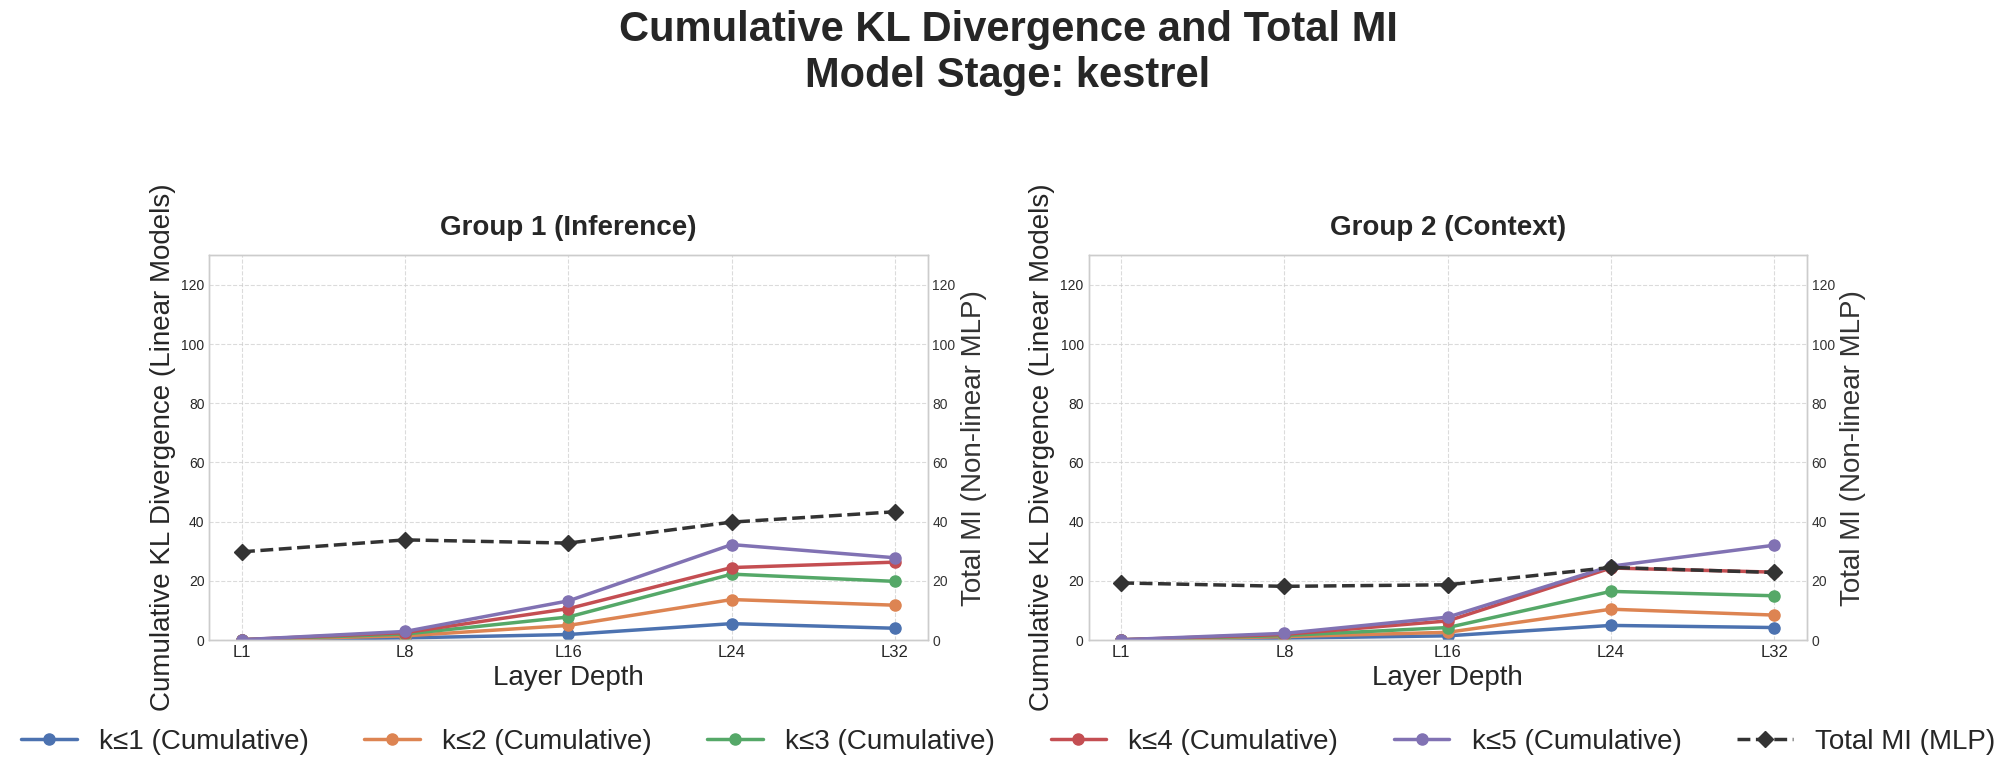

Plotting complete. Cumulative dual-axis plots saved to 'Result/publish/plot/LLM/marin/kl_trends/kestrel.png'.


In [11]:
# ==========================================
# SET MODEL STAGE NAME HERE
# Change this depending on the loaded .pt file (e.g., "Stage 1 (Step 1413814)", "Final Model")
# ==========================================
model_stage_name = "kestrel" 

FIXED_MAX_KL = 130
FIXED_MAX_MI = 130

# ==========================================
# 5. Plot Cumulative KL Divergence Trends using Line Charts (Dual-Axis & Shared Legend)
# ==========================================
print("\n" + "="*60)
print(f"Generating Dual-Axis line plots for CUMULATIVE KL divergence trends... [{model_stage_name}]")
print("="*60)

# Plotting configurations
plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Add a Grand Title (suptitle)
fig.suptitle(f"Cumulative KL Divergence and Total MI\nModel Stage: {model_stage_name}", 
             fontsize=30, fontweight='bold', y=1.05)

# X-axis settings 
x_positions = np.arange(len(plot_layers))
layer_labels = [f"L{l}" for l in plot_layers]

# Color palette 
colors = ['#4c72b0', '#dd8452', '#55a868', '#c44e52', '#8172b3']
total_color = '#333333' 

def plot_kl_trends_dual_cumulative(ax_left, data_dict, title):
    """
    Function to plot a dual-axis chart showing CUMULATIVE KL.
    (Legend creation is removed from here to be shared globally)
    """
    # Initialize an array to keep a running total of KL for each layer
    cumulative_vals = np.zeros(len(x_positions))
    
    # Plot Cumulative KL on the left Y-axis
    for k in range(1, 6):
        # Add the current Step KL to the running total
        cumulative_vals += np.array(data_dict[k])
        ax_left.plot(x_positions, cumulative_vals, marker='o', linewidth=2.5, markersize=8,
                     color=colors[k-1], label=f'k≤{k} (Cumulative)')
        
    ax_left.set_xlabel('Layer Depth', fontsize=20)
    ax_left.set_ylabel('Cumulative KL Divergence (Linear Models)', fontsize=20)
    ax_left.set_xticks(x_positions)
    ax_left.set_xticklabels(layer_labels, fontsize=12)
    ax_left.grid(True, linestyle='--', alpha=0.7)

    # Create the right Y-axis (for Total MI)
    ax_right = ax_left.twinx()
    
    total_vals = data_dict['total_mi']
    ax_right.plot(x_positions, total_vals, marker='D', linestyle='--', linewidth=2.5, markersize=8,
                  color=total_color, label='Total MI (MLP)')
    
    ax_right.set_ylabel('Total MI (Non-linear MLP)', fontsize=20, color=total_color)
    ax_right.tick_params(axis='y', labelcolor=total_color)
    ax_right.grid(False) 
    ax_left.set_ylim(0, FIXED_MAX_KL)
    ax_right.set_ylim(0, FIXED_MAX_MI)
    
    ax_left.set_title(title, fontsize=20, fontweight='bold', pad=15)
    
    # Return ax_right so we can extract its legend handle later
    return ax_right

# Plot for Group 1 (Inference) 
ax1_right = plot_kl_trends_dual_cumulative(ax1, data_g1, 'Group 1 (Inference)')

# Plot for Group 2 (Context) 
ax2_right = plot_kl_trends_dual_cumulative(ax2, data_g2, 'Group 2 (Context)')
handles_left, labels_left = ax1.get_legend_handles_labels()
handles_right, labels_right = ax1_right.get_legend_handles_labels()

fig.legend(handles_left + handles_right, labels_left + labels_right, 
           loc='lower center', 
           bbox_to_anchor=(0.5, -0.05), 
           ncol=6,                      
           fontsize=20)

# Layout adjustment and saving
plt.tight_layout(pad=3.0)
fig.subplots_adjust(bottom=0.15)

# Clean up the string to use it safely in the file name
safe_stage_name = model_stage_name.replace(" ", "_").replace("(", "").replace(")", "").lower()
trend_save_path = f"Result/publish/plot/LLM/marin/kl_trends/{safe_stage_name}.png"

os.makedirs(os.path.dirname(trend_save_path), exist_ok=True)
plt.savefig(trend_save_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Plotting complete. Cumulative dual-axis plots saved to '{trend_save_path}'.")


Generating line plots for Validation MSE trends... [kestrel]


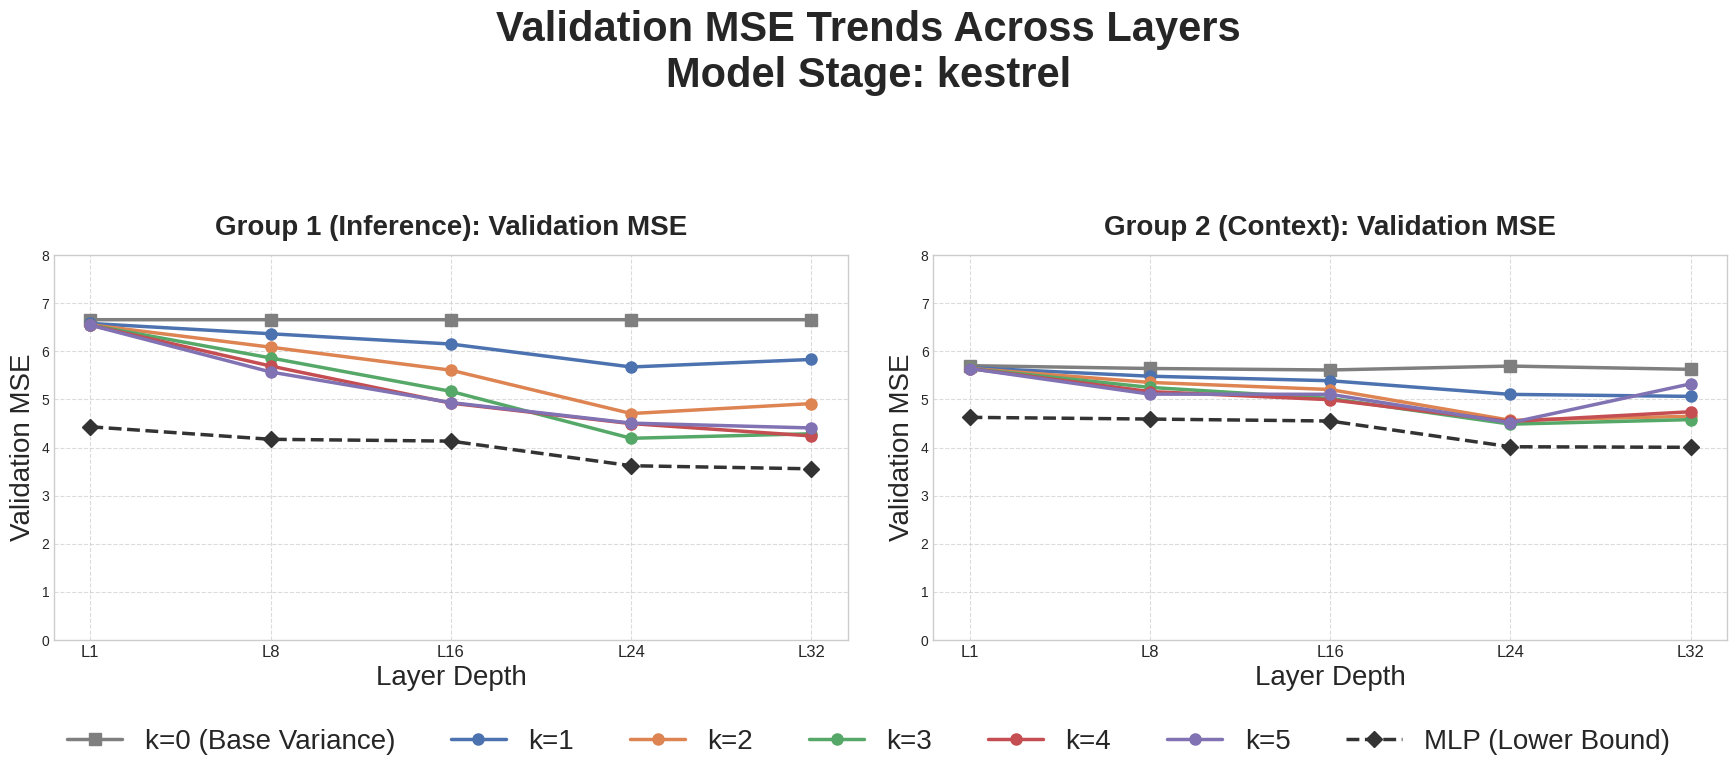

Plotting complete. Validation MSE plots saved to 'Result/publish/plot/LLM/marin/val_mse_trends/kestrel.png'.


In [12]:
FIXED_MAX_MSE = 8.0 

# ==========================================
# 6. Plot Validation MSE Trends using Line Charts (Fixed Scale)
# ==========================================
print("\n" + "="*60)
print(f"Generating line plots for Validation MSE trends... [{model_stage_name}]")
print("="*60)

# Plotting configurations
fig_mse, (ax1_mse, ax2_mse) = plt.subplots(1, 2, figsize=(18, 7))

# Add a Grand Title (suptitle)
fig_mse.suptitle(f"Validation MSE Trends Across Layers\nModel Stage: {model_stage_name}", 
                 fontsize=30, fontweight='bold', y=1.05)

color_k0 = '#7f7f7f' # Gray

def plot_val_mse_trends(ax, data_dict, title):
    """
    Function to plot Validation MSE for k=0~5 and Total MI with FIXED Y-axis limits.
    (Legend creation is removed from here to be shared globally)
    """
    y_vals_k0 = data_dict['val_mse'][0]
    ax.plot(x_positions, y_vals_k0, marker='s', linewidth=2.5, markersize=8,
            color=color_k0, label='k=0 (Base Variance)')
    
    for k in range(1, 6):
        y_vals_k = data_dict['val_mse'][k]
        ax.plot(x_positions, y_vals_k, marker='o', linewidth=2.5, markersize=8,
                color=colors[k-1], label=f'k={k}')
        
    y_vals_mlp = data_dict['val_mse']['Total_MI']
    ax.plot(x_positions, y_vals_mlp, marker='D', linestyle='--', linewidth=2.5, markersize=8,
            color=total_color, label='MLP (Lower Bound)')

    ax.set_title(title, fontsize=20, fontweight='bold', pad=15)
    ax.set_xlabel('Layer Depth', fontsize=20)
    ax.set_ylabel('Validation MSE', fontsize=20)
    
    ax.set_xticks(x_positions)
    ax.set_xticklabels(layer_labels, fontsize=12)
    ax.set_ylim(0, FIXED_MAX_MSE)
    ax.grid(True, linestyle='--', alpha=0.7)

# Plot for Group 1 (Inference)
if 'val_mse' in data_g1:
    plot_val_mse_trends(ax1_mse, data_g1, 'Group 1 (Inference): Validation MSE')
else:
    print("Warning: 'val_mse' data not found in Group 1.")

# Plot for Group 2 (Context)
if 'val_mse' in data_g2:
    plot_val_mse_trends(ax2_mse, data_g2, 'Group 2 (Context): Validation MSE')
else:
    print("Warning: 'val_mse' data not found in Group 2.")

handles, labels = ax1_mse.get_legend_handles_labels()
fig_mse.legend(handles, labels, 
               loc='lower center', 
               bbox_to_anchor=(0.5, -0.05), 
               ncol=7,                      
               fontsize=20)

# Layout adjustment and saving
plt.tight_layout(pad=3.0)
fig_mse.subplots_adjust(bottom=0.15) 

mse_save_path = f"Result/publish/plot/LLM/marin/val_mse_trends/{safe_stage_name}.png"
os.makedirs(os.path.dirname(mse_save_path), exist_ok=True)
plt.savefig(mse_save_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Plotting complete. Validation MSE plots saved to '{mse_save_path}'.")